# 01 — Exploratory Data Analysis & Imputation

Original MSc project notebook. Clinical-feature EDA (age, gender vs the four endpoints), missing-value handling, gender encoding, dataframe merging, and KNN imputation of the microarray matrix. Produces the merged/cleaned dataset consumed downstream.

# **Health Data Analysis Final Project**
## **EDA of clinical features: Age Distribution and Chart**

Maximum age in the dataset: 8983.0 days (24.61 years)
   Age Category  Frequency
0      0-1 year        147
1      1-2 year         86
2      2-3 year         46
3      3-4 year         26
4      4-5 year         30
5      5-6 year         14
6      6-7 year          6
7      7-8 year          3
8      8-9 year          3
9     9-10 year          3
10   10-11 year          2
11   11-12 year          1
12   12-13 year          1
13   13-14 year          1
14   14-15 year          1
15   15-16 year          0
16   16-17 year          0
17   17-18 year          0
18   18-19 year          0
19   19-20 year          0
20   20-21 year          0
21   21-22 year          0
22   22-23 year          1
23   23-24 year          0
24   24-25 year          2


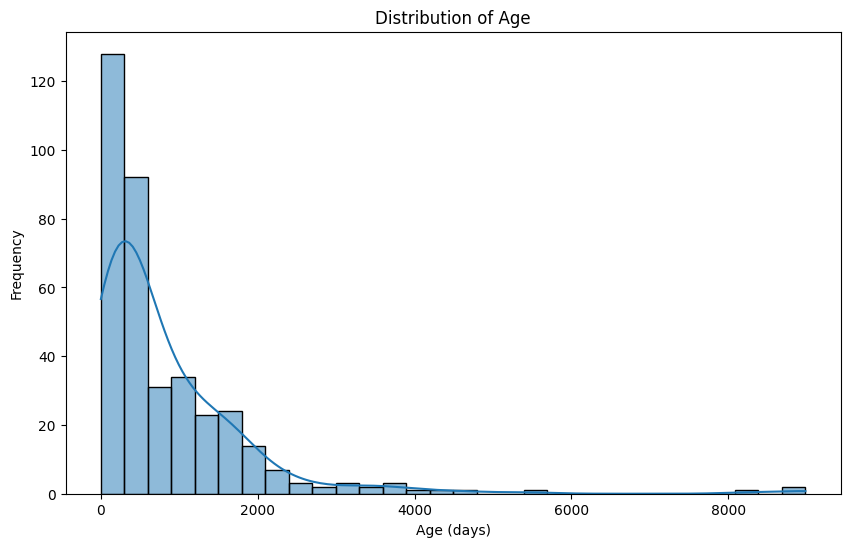

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Determine the range of ages in the dataset
max_age = clinical_data['Age'].max()
print(f"Maximum age in the dataset: {max_age} days ({max_age/365:.2f} years)")

# Define wider age bins to cover all ages
age_bins = list(range(0, int(max_age) + 365, 365))  # Bins for each year up to the maximum age
age_labels = [f'{i}-{i+1} year' for i in range(len(age_bins)-1)]

# Bin the Age data
clinical_data['Age Category'] = pd.cut(clinical_data['Age'], bins=age_bins, labels=age_labels, right=False)

# Create a frequency table for the age categories
age_category_counts = clinical_data['Age Category'].value_counts().sort_index()

# Convert to a DataFrame for better display
age_category_table = pd.DataFrame({'Age Category': age_category_counts.index, 'Frequency': age_category_counts.values})

# Display the table
print(age_category_table)

# Plot the distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(clinical_data['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age (days)')
plt.ylabel('Frequency')
plt.show()

# **EDA of clinical features: Comparison of age against predicted outcomes**

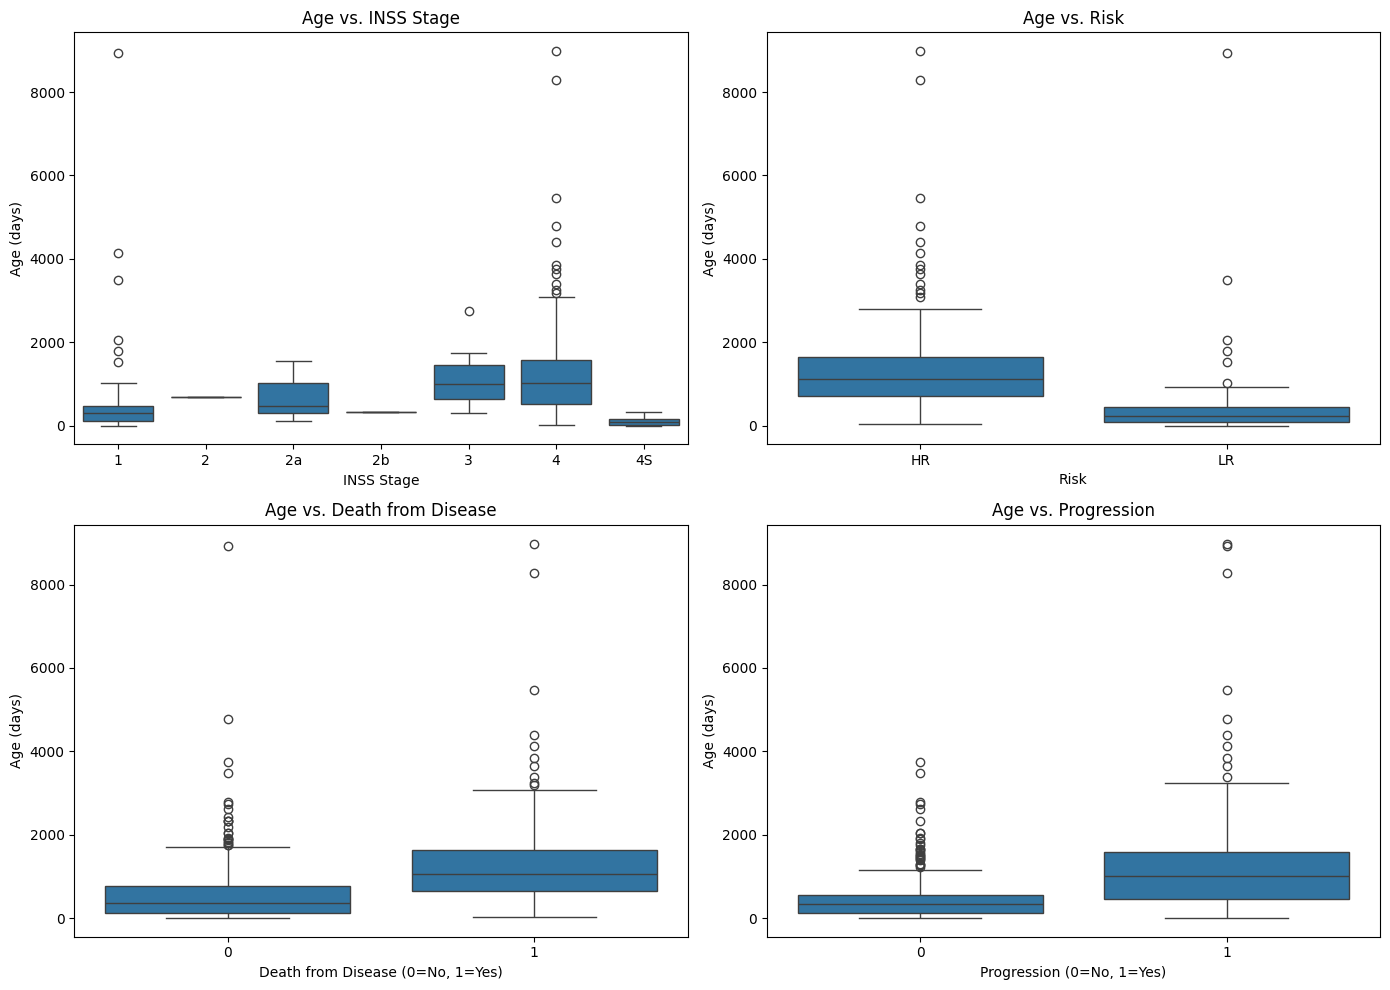

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Define the desired order for INSS Stage
inss_stage_order = ['1', '2', '2a', '2b', '3', '4', '4S']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Box plot of Age vs. INSS Stage with specified order
sns.boxplot(x='INSS.Stage', y='Age', data=clinical_data, order=inss_stage_order, ax=axs[0, 0])
axs[0, 0].set_title('Age vs. INSS Stage')
axs[0, 0].set_xlabel('INSS Stage')
axs[0, 0].set_ylabel('Age (days)')

# Box plot of Age vs. HighRisk
sns.boxplot(x='HighRisk', y='Age', data=clinical_data, ax=axs[0, 1])
axs[0, 1].set_title('Age vs. Risk')
axs[0, 1].set_xlabel('Risk')
axs[0, 1].set_ylabel('Age (days)')

# Box plot of Age vs. DeathFromDisease
sns.boxplot(x='DeathFromDisease', y='Age', data=clinical_data, ax=axs[1, 0])
axs[1, 0].set_title('Age vs. Death from Disease')
axs[1, 0].set_xlabel('Death from Disease (0=No, 1=Yes)')
axs[1, 0].set_ylabel('Age (days)')

# Box plot of Age vs. Progression
sns.boxplot(x='Progression', y='Age', data=clinical_data, ax=axs[1, 1])
axs[1, 1].set_title('Age vs. Progression')
axs[1, 1].set_xlabel('Progression (0=No, 1=Yes)')
axs[1, 1].set_ylabel('Age (days)')

# Adjust layout
plt.tight_layout()
plt.show()

## **EDA of clinical features: Comparison of Gender against predicted outcomes**

<ipython-input-15-9a566f4681f8>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=clinical_data, palette=gender_palette)


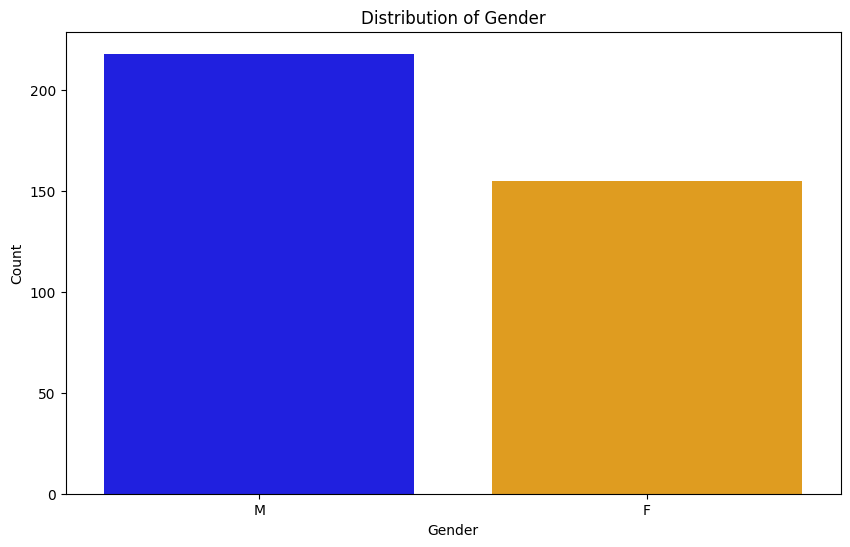

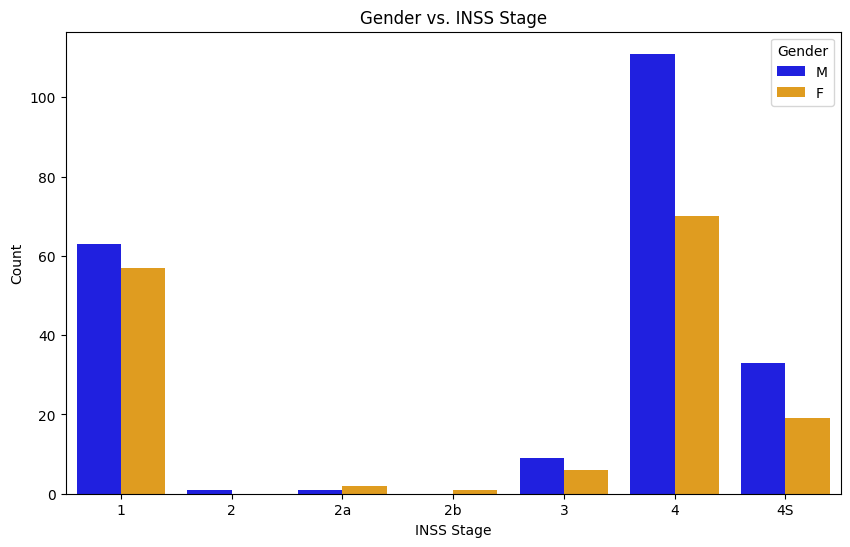

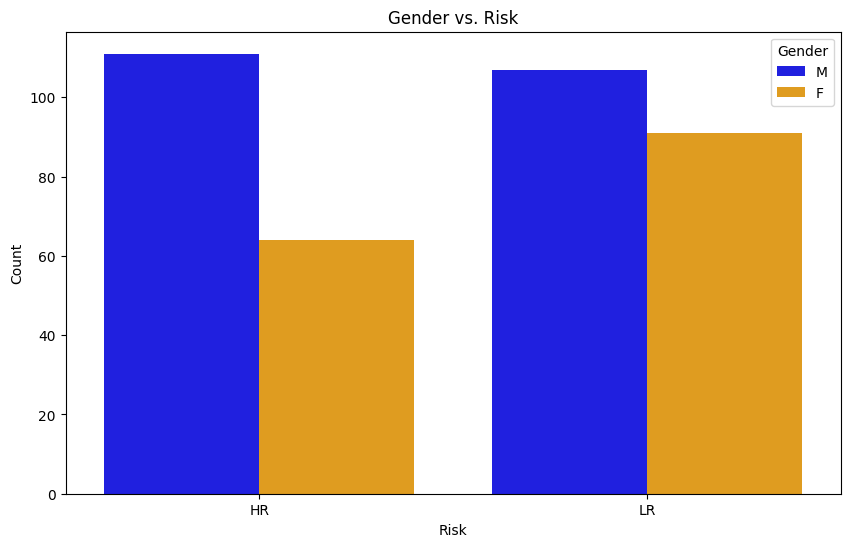

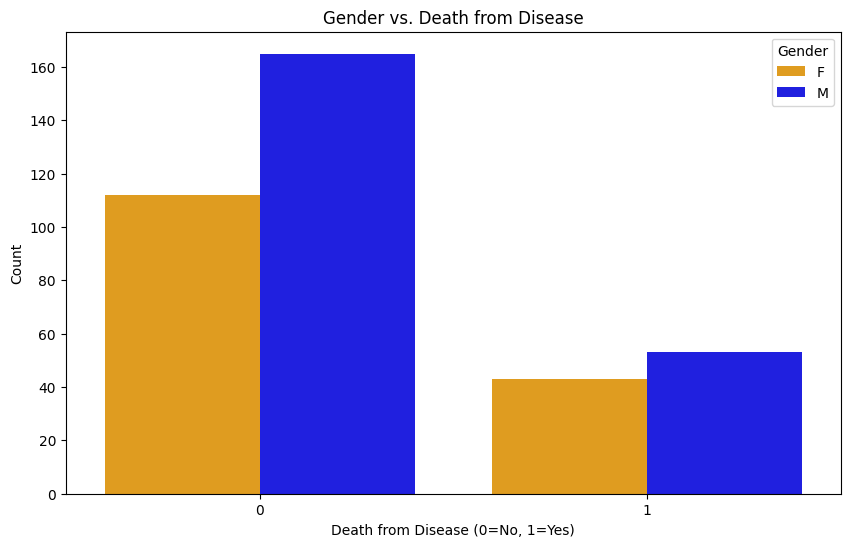

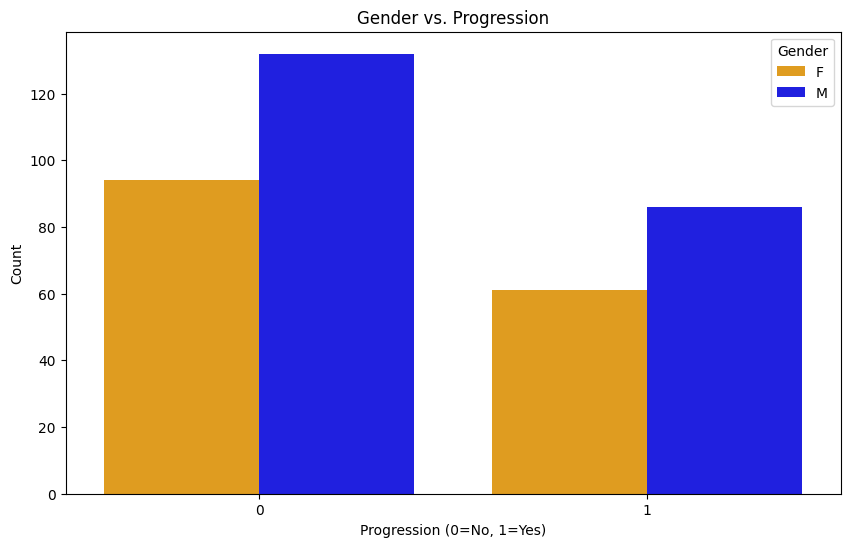

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Define the desired order for INSS Stage
inss_stage_order = ['1', '2', '2a', '2b', '3', '4', '4S']

# Custom color palette
gender_palette = {'M': 'blue', 'F': 'orange'}

# Plot the distribution of Gender
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', data=clinical_data, palette=gender_palette)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Bar plot of Gender vs. INSS Stage
plt.figure(figsize=(10, 6))
sns.countplot(x='INSS.Stage', hue='Gender', data=clinical_data, palette=gender_palette, order=inss_stage_order)
plt.title('Gender vs. INSS Stage')
plt.xlabel('INSS Stage')
plt.ylabel('Count')
plt.show()

# Bar plot of Gender vs. HighRisk
plt.figure(figsize=(10, 6))
sns.countplot(x='HighRisk', hue='Gender', data=clinical_data, palette=gender_palette)
plt.title('Gender vs. Risk')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.show()

# Bar plot of Gender vs. DeathFromDisease
plt.figure(figsize=(10, 6))
sns.countplot(x='DeathFromDisease', hue='Gender', data=clinical_data, palette=gender_palette)
plt.title('Gender vs. Death from Disease')
plt.xlabel('Death from Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# Bar plot of Gender vs. Progression
plt.figure(figsize=(10, 6))
sns.countplot(x='Progression', hue='Gender', data=clinical_data, palette=gender_palette)
plt.title('Gender vs. Progression')
plt.xlabel('Progression (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## **Stat Analysis for Relationship of Age and Gender indiviudally with Clinical Endpoints**

In [ ]:
import pandas as pd
import scipy.stats as stats

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Create a mapping for INSS stages to integers
inss_stage_mapping = {
    '1': 1, '2': 2, '2a': 3, '2b': 4, '3': 5, '4': 6, '4S': 7
}

# Apply the mapping to the INSS Stage column
clinical_data['INSS.Stage.Numeric'] = clinical_data['INSS.Stage'].map(inss_stage_mapping)

# Correlation between Age and clinical features
age_correlation_inss = clinical_data['Age'].corr(clinical_data['INSS.Stage.Numeric'])
age_correlation_risk = clinical_data['Age'].corr(clinical_data['HighRisk'].apply(lambda x: 1 if x == 'HR' else 0))
age_correlation_death = clinical_data['Age'].corr(clinical_data['DeathFromDisease'])
age_correlation_progression = clinical_data['Age'].corr(clinical_data['Progression'])

print(f"Correlation between Age and INSS Stage: {age_correlation_inss:.2f}")
print(f"Correlation between Age and Risk: {age_correlation_risk:.2f}")
print(f"Correlation between Age and Death from Disease: {age_correlation_death:.2f}")
print(f"Correlation between Age and Progression: {age_correlation_progression:.2f}")

# Chi-square test for Gender and clinical features
chi2_inss, p_inss = stats.chi2_contingency(pd.crosstab(clinical_data['Gender'], clinical_data['INSS.Stage']))[0:2]
chi2_risk, p_risk = stats.chi2_contingency(pd.crosstab(clinical_data['Gender'], clinical_data['HighRisk']))[0:2]
chi2_death, p_death = stats.chi2_contingency(pd.crosstab(clinical_data['Gender'], clinical_data['DeathFromDisease']))[0:2]
chi2_progression, p_progression = stats.chi2_contingency(pd.crosstab(clinical_data['Gender'], clinical_data['Progression']))[0:2]

print(f"Chi-square test for Gender and INSS Stage: chi2={chi2_inss:.2f}, p={p_inss:.4f}")
print(f"Chi-square test for Gender and Risk: chi2={chi2_risk:.2f}, p={p_risk:.4f}")
print(f"Chi-square test for Gender and Death from Disease: chi2={chi2_death:.2f}, p={p_death:.4f}")
print(f"Chi-square test for Gender and Progression: chi2={chi2_progression:.2f}, p={p_progression:.4f}")

Correlation between Age and INSS Stage: 0.18
Correlation between Age and Risk: 0.48
Correlation between Age and Death from Disease: 0.33
Correlation between Age and Progression: 0.36
Chi-square test for Gender and INSS Stage: chi2=5.81, p=0.4442
Chi-square test for Gender and Risk: chi2=3.00, p=0.0835
Chi-square test for Gender and Death from Disease: chi2=0.39, p=0.5309
Chi-square test for Gender and Progression: chi2=0.00, p=1.0000


# **Check for and handle any missing values in Age and Gender**

In [ ]:

import pandas as pd

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Display the first few rows of the clinical data
print(clinical_data.head())

# Check for missing values in Age and Gender columns
missing_values = clinical_data[['Age', 'Gender']].isnull().sum()
print(f"Missing values in Age and Gender columns:\n{missing_values}")

# Impute missing values
# Fill missing Age values with the median Age
median_age = clinical_data['Age'].median()
clinical_data['Age'].fillna(median_age, inplace=True)

# Fill missing Gender values with the mode (most frequent Gender)
mode_gender = clinical_data['Gender'].mode()[0]
clinical_data['Gender'].fillna(mode_gender, inplace=True)

# Verify that there are no missing values left
missing_values_after = clinical_data[['Age', 'Gender']].isnull().sum()
print(f"Missing values after imputation:\n{missing_values_after}")

         ID Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001      M   987.0                      ST4           1          4   
1  ICGC_002      M  1808.0                      ST4           1          4   
2  ICGC_003      F   625.0                      MNA         Amp          4   
3  ICGC_004      F   335.0                      MNA         Amp         2b   
4  ICGC_005      F   536.0                      MNA         Amp          4   

  HighRisk  Progression  DeathFromDisease  
0       HR            1                 1  
1       HR            1                 1  
2       HR            1                 1  
3       HR            0                 0  
4       HR            1                 1  
Missing values in Age and Gender columns:
Age       0
Gender    0
dtype: int64
Missing values after imputation:
Age       0
Gender    0
dtype: int64


# **Convert Gender to numerical values (e.g., 0 for Male, 1 for Female).**

In [ ]:
import pandas as pd

# Load the clinical dataset
clinical_data = pd.read_csv('clinical_data.csv')

# Display the first few rows of the clinical data
print(clinical_data.head())

# Create a mapping dictionary for Gender
gender_mapping = {'M': 0, 'F': 1}

# Apply the mapping to the Gender column
clinical_data['Gender'] = clinical_data['Gender'].map(gender_mapping)

# Display the first few rows of the transformed data
print(clinical_data.head())

# Save the modified DataFrame to a new CSV file
clinical_data.to_csv('clinical_data_with_conversions.csv', index=False)


         ID Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001      M   987.0                      ST4           1          4   
1  ICGC_002      M  1808.0                      ST4           1          4   
2  ICGC_003      F   625.0                      MNA         Amp          4   
3  ICGC_004      F   335.0                      MNA         Amp         2b   
4  ICGC_005      F   536.0                      MNA         Amp          4   

  HighRisk  Progression  DeathFromDisease  
0       HR            1                 1  
1       HR            1                 1  
2       HR            1                 1  
3       HR            0                 0  
4       HR            1                 1  
         ID  Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001       0   987.0                      ST4           1          4   
1  ICGC_002       0  1808.0                      ST4           1          4   
2  ICGC_003       1   625.0   

In [ ]:
import pandas as pd

# Load the raw gene expression dataset
raw_data = pd.read_csv('raw_data.csv')

# Display the first few rows of the raw data
print(raw_data.head())

# Count unique GeneSymbols values
unique_gene_symbols = raw_data['GeneSymbols'].nunique()

# Display the count
print(f"Number of unique GeneSymbols values: {unique_gene_symbols}")

   Reporter.Identifier GeneSymbols  ICGC_001_TCGA  ICGC_002_TCGA  \
0                  NaN         NaN          14.99          14.94   
1              27262.0         NaN           9.20          10.41   
2               3180.0         NaN           5.06           5.26   
3              41426.0         NaN           7.45           8.68   
4              37033.0         NaN           6.74           6.63   

   ICGC_003_TCGA  ICGC_004  ICGC_005  ICGC_006  ICGC_007  ICGC_008  ...  \
0          12.48     14.63     11.89     15.09     13.07     12.00  ...   
1           9.27      8.83       NaN     10.33      9.62      8.72  ...   
2           6.45      2.89      2.00      4.80      3.05      6.39  ...   
3           6.30      7.30      6.26      7.50      7.43      6.98  ...   
4           6.75      6.20      6.57      6.01      6.78      4.80  ...   

   ICGC_489  ICGC_490  ICGC_491_TCGA  ICGC_492  ICGC_493  ICGC_494_TCGA  \
0     13.62     13.03          14.98     13.36     13.90         

In [ ]:
# Load the raw gene expression dataset
raw_data = pd.read_csv('raw_data.csv')

# Display the first few rows of the raw data
print(raw_data.head())

# Count unique GeneSymbols values
Reporter_Identifier = raw_data['Reporter.Identifier'].nunique()

# Display the count
print(f"Number of unique Reporter_Identifier values: {Reporter_Identifier}")

   Reporter.Identifier GeneSymbols  ICGC_001_TCGA  ICGC_002_TCGA  \
0                  NaN         NaN          14.99          14.94   
1              27262.0         NaN           9.20          10.41   
2               3180.0         NaN           5.06           5.26   
3              41426.0         NaN           7.45           8.68   
4              37033.0         NaN           6.74           6.63   

   ICGC_003_TCGA  ICGC_004  ICGC_005  ICGC_006  ICGC_007  ICGC_008  ...  \
0          12.48     14.63     11.89     15.09     13.07     12.00  ...   
1           9.27      8.83       NaN     10.33      9.62      8.72  ...   
2           6.45      2.89      2.00      4.80      3.05      6.39  ...   
3           6.30      7.30      6.26      7.50      7.43      6.98  ...   
4           6.75      6.20      6.57      6.01      6.78      4.80  ...   

   ICGC_489  ICGC_490  ICGC_491_TCGA  ICGC_492  ICGC_493  ICGC_494_TCGA  \
0     13.62     13.03          14.98     13.36     13.90         

# **Preparing Data Frames**


In [ ]:
import pandas as pd

# Load the raw gene expression dataset
raw_data = pd.read_csv('raw_data.csv')

# Create an ascending order index column
raw_data['Gene_Num'] = range(1, len(raw_data) + 1)

# Reorder the columns to place the new index column first
cols = raw_data.columns.tolist()
cols = cols[-1:] + cols[:-1]  # Move the last column (Index) to the first position
raw_data = raw_data[cols]

# Display the first few rows to verify the new order
print(raw_data.head())

# Save the modified DataFrame to a new CSV file
raw_data.to_csv('raw_data_with_index.csv', index=False)

   Gene_Num  Reporter.Identifier GeneSymbols  ICGC_001_TCGA  ICGC_002_TCGA  \
0         1                  NaN         NaN          14.99          14.94   
1         2              27262.0         NaN           9.20          10.41   
2         3               3180.0         NaN           5.06           5.26   
3         4              41426.0         NaN           7.45           8.68   
4         5              37033.0         NaN           6.74           6.63   

   ICGC_003_TCGA  ICGC_004  ICGC_005  ICGC_006  ICGC_007  ...  ICGC_489  \
0          12.48     14.63     11.89     15.09     13.07  ...     13.62   
1           9.27      8.83       NaN     10.33      9.62  ...      6.26   
2           6.45      2.89      2.00      4.80      3.05  ...      0.93   
3           6.30      7.30      6.26      7.50      7.43  ...      5.35   
4           6.75      6.20      6.57      6.01      6.78  ...      4.58   

   ICGC_490  ICGC_491_TCGA  ICGC_492  ICGC_493  ICGC_494_TCGA  ICGC_495  \
0    

In [ ]:
import pandas as pd

# Load the modified gene expression dataset with index
raw_data = pd.read_csv('raw_data_with_index.csv')

# Display the first few rows to verify the data
print(raw_data.head())

# Transpose the DataFrame
transposed_data = raw_data.transpose()

# Display the first few rows of the transposed DataFrame to verify
print(transposed_data.head())

# Save the transposed DataFrame to a new CSV file
transposed_data.to_csv('transposed_raw_data_with_index.csv', header=False)

   Gene_Num  Reporter.Identifier GeneSymbols  ICGC_001_TCGA  ICGC_002_TCGA  \
0         1                  NaN         NaN          14.99          14.94   
1         2              27262.0         NaN           9.20          10.41   
2         3               3180.0         NaN           5.06           5.26   
3         4              41426.0         NaN           7.45           8.68   
4         5              37033.0         NaN           6.74           6.63   

   ICGC_003_TCGA  ICGC_004  ICGC_005  ICGC_006  ICGC_007  ...  ICGC_489  \
0          12.48     14.63     11.89     15.09     13.07  ...     13.62   
1           9.27      8.83       NaN     10.33      9.62  ...      6.26   
2           6.45      2.89      2.00      4.80      3.05  ...      0.93   
3           6.30      7.30      6.26      7.50      7.43  ...      5.35   
4           6.75      6.20      6.57      6.01      6.78  ...      4.58   

   ICGC_490  ICGC_491_TCGA  ICGC_492  ICGC_493  ICGC_494_TCGA  ICGC_495  \
0    

# **Merge Dataframes**

In [ ]:
import pandas as pd

# Load the transposed raw gene expression dataset
transposed_raw_data = pd.read_csv('transposed_raw_data_with_index.csv', header=None)

# Assume the first row is the header in the transposed data
transposed_raw_data.columns = transposed_raw_data.iloc[0]
transposed_raw_data = transposed_raw_data[1:]

# Set the first column of transposed_raw_data as the index
transposed_raw_data.set_index(transposed_raw_data.columns[0], inplace=True)

# Remove '_TCGA' from the first column values if present
transposed_raw_data.index = transposed_raw_data.index.str.replace('_TCGA', '')

# Save the modified dataframe to a new CSV file for verification
transposed_raw_data.to_csv('transposed_raw_data_no_tcga.csv')

print('Successfully removed _TCGA from ICGC IDs and saved the new dataframe.')



<ipython-input-21-a9d8f08f505d>:4: DtypeWarning: Columns (8,15,18,20,28,33,38,39,44,46,47,53,55,58,73,74,77,78,88,99,103,108,114,115,117,121,123,126,128,136,140,143,151,152,157,159,160,164,167,168,172,187,190,191,194,196,199,200,202,206,207,208,211,216,217,221,230,231,234,237,240,241,245,248,249,257,259,262,266,277,281,282,291,305,309,310,311,319,324,329,330,338,340,352,354,364,374,385,396,402,407,417,423,425,428,433,442,447,449,454,457,463,468,470,480,489,501,502,504,506,509,523,525,530,531,534,541,550,553,556,576,582,588,591,593,596,598,599,605,607,627,633,636,637,648,678,685,700,705,709,720,736,738,739,741,747,754,766,780,785,789,792,800,801,808,819,820,821,824,827,829,831,843,847,849,851,853,864,865,871,873,879,885,887,888,889,893,900,905,906,907,909,915,916,917,919,923,924,929,930,938,941,945,947,963,966,970,971,975,980,1003,1014,1016,1024,1038,1052,1055,1058,1067,1068,1069,1073,1075,1084,1086,1093,1095,1111,1116,1118,1121,1122,1134,1141,1146,1149,1156,1161,1163,1164,1178,1181,118

Successfully removed _TCGA from ICGC IDs and saved the new dataframe.


In [ ]:
import pandas as pd

# Load the modified dataframe
transposed_raw_data = pd.read_csv('transposed_raw_data_no_tcga.csv', index_col=0)

# List of ICGC IDs to be removed
icgc_ids_to_remove = [
 'ICGC_011', 'ICGC_014', 'ICGC_017', 'ICGC_018', 'ICGC_039', 'ICGC_040', 'ICGC_041', 'ICGC_042', 'ICGC_043', 'ICGC_044',
 'ICGC_045', 'ICGC_046', 'ICGC_047', 'ICGC_048', 'ICGC_049', 'ICGC_061', 'ICGC_062', 'ICGC_063', 'ICGC_064', 'ICGC_065',
 'ICGC_066', 'ICGC_067', 'ICGC_068', 'ICGC_069', 'ICGC_070', 'ICGC_071', 'ICGC_072', 'ICGC_073', 'ICGC_074', 'ICGC_075',
 'ICGC_076', 'ICGC_077', 'ICGC_078', 'ICGC_079', 'ICGC_112', 'ICGC_115', 'ICGC_116', 'ICGC_117', 'ICGC_118', 'ICGC_119',
 'ICGC_120', 'ICGC_121', 'ICGC_122', 'ICGC_123', 'ICGC_124', 'ICGC_125', 'ICGC_126', 'ICGC_127', 'ICGC_128', 'ICGC_129',
 'ICGC_130', 'ICGC_131', 'ICGC_132', 'ICGC_134', 'ICGC_135', 'ICGC_141', 'ICGC_142', 'ICGC_145', 'ICGC_146', 'ICGC_147',
 'ICGC_148', 'ICGC_149', 'ICGC_150', 'ICGC_151', 'ICGC_170', 'ICGC_171', 'ICGC_173', 'ICGC_174', 'ICGC_176', 'ICGC_177',
 'ICGC_178', 'ICGC_179', 'ICGC_180', 'ICGC_181', 'ICGC_182', 'ICGC_183', 'ICGC_184', 'ICGC_185', 'ICGC_186', 'ICGC_187',
 'ICGC_188', 'ICGC_189', 'ICGC_190', 'ICGC_191', 'ICGC_192', 'ICGC_193', 'ICGC_212', 'ICGC_217', 'ICGC_218', 'ICGC_219',
 'ICGC_220', 'ICGC_221', 'ICGC_222', 'ICGC_223', 'ICGC_225', 'ICGC_226', 'ICGC_227', 'ICGC_228', 'ICGC_229', 'ICGC_230',
 'ICGC_231', 'ICGC_232', 'ICGC_233', 'ICGC_234', 'ICGC_255', 'ICGC_312', 'ICGC_315', 'ICGC_317', 'ICGC_349', 'ICGC_350',
 'ICGC_353', 'ICGC_356', 'ICGC_357', 'ICGC_358', 'ICGC_361', 'ICGC_382', 'ICGC_395', 'ICGC_416', 'ICGC_419', 'ICGC_450',
 'ICGC_451', 'ICGC_453', 'ICGC_474', 'ICGC_476', 'ICGC_477'
]

# Remove the specified ICGC IDs from the dataframe
transposed_raw_data = transposed_raw_data[~transposed_raw_data.index.isin(icgc_ids_to_remove)]

# Check the size of the new dataframe
new_size = transposed_raw_data.shape

# Save the modified dataframe for verification
transposed_raw_data.to_csv('transposed_raw_data_filtered.csv')

print(f'The size of the new dataframe is: {new_size}')

<ipython-input-22-e13e2c3e115b>:4: DtypeWarning: Columns (8,15,18,20,28,33,38,39,44,46,47,53,55,58,73,74,77,78,88,99,103,108,114,115,117,121,123,126,128,136,140,143,151,152,157,159,160,164,167,168,172,187,190,191,194,196,199,200,202,206,207,208,211,216,217,221,230,231,234,237,240,241,245,248,249,257,259,262,266,277,281,282,291,305,309,310,311,319,324,329,330,338,340,352,354,364,374,385,396,402,407,417,423,425,428,433,442,447,449,454,457,463,468,470,480,489,501,502,504,506,509,523,525,530,531,534,541,550,553,556,576,582,588,591,593,596,598,599,605,607,627,633,636,637,648,678,685,700,705,709,720,736,738,739,741,747,754,766,780,785,789,792,800,801,808,819,820,821,824,827,829,831,843,847,849,851,853,864,865,871,873,879,885,887,888,889,893,900,905,906,907,909,915,916,917,919,923,924,929,930,938,941,945,947,963,966,970,971,975,980,1003,1014,1016,1024,1038,1052,1055,1058,1067,1068,1069,1073,1075,1084,1086,1093,1095,1111,1116,1118,1121,1122,1134,1141,1146,1149,1156,1161,1163,1164,1178,1181,118

The size of the new dataframe is: (375, 44708)


In [ ]:
import pandas as pd

# Load the transposed_raw_data_filtered.csv file
transposed_raw_data = pd.read_csv('transposed_raw_data_filtered.csv', header=None)

# Create 8 new columns with 375 rows of NaN values
new_cols = pd.DataFrame([[None] * 8 for _ in range(transposed_raw_data.shape[0])])

# Concatenate the new columns to the original data at the specified position
updated_data = pd.concat([transposed_raw_data.iloc[:, :1], new_cols, transposed_raw_data.iloc[:, 1:]], axis=1)

# Save the updated dataframe to a new CSV file
updated_data.to_csv('transposed_raw_data_with_new_cols.csv', index=False, header=False)

# Display the size of the updated dataframe
print("Dataframe size:", updated_data.shape)

# Display the head of the updated dataframe
print("Head of the updated dataframe:")
print(updated_data.head())

In [ ]:
import pandas as pd

# Load the transposed_raw_data_with_new_cols.csv file
transposed_raw_data = pd.read_csv('transposed_raw_data_with_new_cols.csv', header=None)

# Define the column headings
column_headings = ['Gender', 'Age', 'Clinico.genetic.subgroup', 'MYCN.status', 'INSS.stage', 'HighRisk', 'Progression', 'Deathfromdisease']

# Insert the column headings into the first row, columns 2 to 9
for i, heading in enumerate(column_headings):
    transposed_raw_data.iloc[0, i+1] = heading

# Save the updated dataframe to a new CSV file
transposed_raw_data.to_csv('transposed_raw_data_with_headings.csv', index=False, header=False)

# Display the size of the dataframe
print("Dataframe size:", transposed_raw_data.shape)

# Display the head of the dataframe
print("Head of the dataframe:")
print(transposed_raw_data.head())

In [ ]:
import pandas as pd

# Load the transposed_raw_data_with_headings.csv
transposed_raw_data = pd.read_csv('transposed_raw_data_with_headings.csv', header=None)

# Load the clinical_data_with_conversions.csv
clinical_data = pd.read_csv('clinical_data_with_conversions.csv')

# Select the relevant columns (assuming columns 2 to 9 in clinical_data which are 1-indexed)
clinical_data_selected = clinical_data.iloc[:, 1:9]

# Ensure the number of rows matches by selecting the first 373 rows if there are more
clinical_data_selected = clinical_data_selected.iloc[:373, :]

# Insert the clinical data into the specified range (row 3 to row 375, col 2 to col 9)
transposed_raw_data.iloc[2:375, 1:9] = clinical_data_selected.values

# Save the updated dataframe to a new CSV file
transposed_raw_data.to_csv('transposed_raw_data_with_clinical_data.csv', index=False, header=False)

# Display the size of the dataframe
print("Dataframe size:", transposed_raw_data.shape)

# Display the head of the dataframe
print("Head of the dataframe:")
print(transposed_raw_data.head())

In [ ]:
import pandas as pd

# Load the transposed_raw_data_with_headings.csv
transposed_raw_data = pd.read_csv('transposed_raw_data_with_headings.csv', header=None)

# Load the clinical_data_with_conversions.csv
clinical_data = pd.read_csv('clinical_data_with_conversions.csv')

# Select the relevant columns (assuming columns 2 to 9 in clinical_data which are 1-indexed)
clinical_data_selected = clinical_data.iloc[:, 1:9]

# Ensure the number of rows matches by selecting the first 372 rows if there are more
clinical_data_selected = clinical_data_selected.iloc[:372, :]

# Insert the clinical data into the specified range (row 4 to row 375, col 2 to col 9)
transposed_raw_data.iloc[3:375, 1:9] = clinical_data_selected.values

# Save the updated dataframe to a new CSV file
transposed_raw_data.to_csv('transposed_raw_data_with_clinical_data.csv', index=False, header=False)

# Display the size of the dataframe
print("Dataframe size:", transposed_raw_data.shape)

# Display the head of the dataframe
print("Head of the dataframe:")
print(transposed_raw_data.head())

In [ ]:
import pandas as pd

# Load the merged dataset
merged_data = pd.read_csv('transposed_raw_data_with_clinical_data.csv')

# Define the values to be inserted
values_to_insert = ['1', '530', 'ST1', '1', '1', 'LR', '0', '0']

# Insert the values at row 375 in columns 2 to 9 (Python uses 0-based indexing)
merged_data.iloc[374, 1:9] = values_to_insert

# Save the updated dataframe to a new CSV file
merged_data.to_csv('transposed_raw_data_with_clinical_data_updated.csv', index=False)

print("Values inserted successfully.")

In [ ]:
import pandas as pd

# Load the merged dataset
merged_data = pd.read_csv('Merged Data Final Version.csv')

# Get the dimensions of the merged dataset
dimensions = merged_data.shape

print("Dimensions of the merged dataset:", dimensions)

In [ ]:
import pandas as pd

# Load the merged dataset with low_memory set to False
merged_data = pd.read_csv('Merged Data Final Version.csv', low_memory=False)

# Display the dataframe dimensions
print("Dimensions of the merged data frame:", merged_data.shape)

# **Visualisation of High dimensional Data**

In [ ]:
import pandas as pd

# Load the merged data
merged_data = pd.read_csv('Merged Data Final Version.csv',low_memory=False)

# Melt the dataframe
melted_data = pd.melt(merged_data,
                      id_vars=['Gender', 'Age', 'Clinico.genetic.subgroup', 'MYCN.status', 'INSS.stage', 'HighRisk', 'Progression', 'Deathfromdisease'],
                      var_name='Gene',
                      value_name='Expression')

# Display the head of the melted dataframe
print(melted_data.head())

# Display the shape of the melted dataframe
print("Shape of the melted dataframe:", melted_data.shape)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Expression column is numeric
melted_data['Expression'] = pd.to_numeric(melted_data['Expression'], errors='coerce')

# Drop any rows with NaN values in the Expression column
filtered_data = melted_data.dropna(subset=['Expression'])

# Create the box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Expression', y='Gene', data=filtered_data)
plt.xticks(rotation=90)
plt.xlabel('ICGC IDs')
plt.ylabel('Gene Expression')
plt.title('Gene Expression across ICGC IDs')
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))
sns.violinplot(x='Gene', y='Expression', data=top_filtered_data)
plt.xticks(rotation=90)
plt.xlabel('Gene')
plt.ylabel('Gene Expression')
plt.title('Gene Expression for Top 10 Most Variable Genes')
plt.show()

# **Data Preprocessing- check for missing values**

In [ ]:
import pandas as pd

# Load the data
merged_data = pd.read_csv('Merge_data.csv', low_memory=False)

# Select clinical features columns
clinical_features = ['Gender', 'Age', 'Clinico.genetic.subgroup', 'MYCN.status', 'INSS.stage', 'HighRisk', 'Progression', 'Deathfromdisease']

# Check for missing values in clinical features
missing_values = merged_data[clinical_features].isnull().sum()

print("Missing values in clinical features:")
print(missing_values)

In [ ]:
import pandas as pd

# Load the data
merged_data = pd.read_csv('Merge_data.csv')

# Select clinical features columns
clinical_features = ['Gender', 'Age', 'Clinico.genetic.subgroup', 'MYCN.status', 'INSS.stage', 'HighRisk', 'Progression', 'Deathfromdisease']

# Select microarray data columns by excluding clinical features
microarray_data = merged_data.drop(columns=clinical_features)

# Check for missing values in microarray data
missing_values_microarray = microarray_data.isnull().sum()

print("Missing values in microarray data:")
print(missing_values_microarray)

In [ ]:
import pandas as pd

# Load the data
merged_data = pd.read_csv('Merge_data.csv', low_memory=False)

# Define the threshold for missing values (e.g., if more than 50% of the data in a column is missing, drop that column)
threshold = 0.5

# Calculate the proportion of missing values for each column
missing_values_ratio = merged_data.isnull().mean()

# Identify columns to drop
columns_to_drop = missing_values_ratio[missing_values_ratio > threshold].index

# Drop the identified columns
cleaned_data = merged_data.drop(columns=columns_to_drop)

# Save the cleaned data to a new CSV file
cleaned_data.to_csv('Merge_data_cleaned.csv', index=False)

print("Columns with more than 50% missing values have been removed. Cleaned data saved to 'Merge_data_cleaned.csv'.")

# **KNN Imputation of Missing Values**

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Load the cleaned data
cleaned_data = pd.read_csv('Merge_data_cleaned.csv', low_memory=False)

# Define the columns that are clinical features
clinical_features = ['Gender', 'Age', 'Clinico.genetic.subgroup', 'MYCN.status', 'INSS.stage', 'HighRisk', 'Progression', 'Deathfromdisease']

# Separate the clinical features and the gene expression data
clinical_data = cleaned_data[clinical_features]
expression_data = cleaned_data.drop(columns=clinical_features)

# Inspect the columns of the expression data
print("Expression data columns:", expression_data.columns)

# Convert the gene expression data to numeric, forcing errors to NaN
expression_data.iloc[2:, :] = expression_data.iloc[2:, :].apply(pd.to_numeric, errors='coerce')

# Verify if any non-numeric columns exist after the conversion
non_numeric_cols = expression_data.select_dtypes(exclude=['number']).columns
print("Non-numeric columns after conversion:", non_numeric_cols)

# Perform KNN imputation on the gene expression data, skipping the first two rows
imputer = KNNImputer(n_neighbors=5)
imputed_values = imputer.fit_transform(expression_data.iloc[2:, :])

# Debugging information
print("Original expression_data shape:", expression_data.shape)
print("Imputed values shape:", imputed_values.shape)

# Ensure the imputed values have the correct shape and replace the original data
if imputed_values.shape[1] == expression_data.shape[1]:
    expression_data.iloc[2:, :] = imputed_values
else:
    print("Shape mismatch between imputed values and original expression data. Adjusting columns.")
    imputed_df = pd.DataFrame(imputed_values, columns=expression_data.columns[1:])
    expression_data.iloc[2:, 1:] = imputed_df

# Debugging information
print("Updated expression_data shape:", expression_data.shape)

# Recombine the clinical data and the expression data
imputed_data = pd.concat([clinical_data, expression_data], axis=1)

# Save the imputed data to a new CSV file
imputed_data.to_csv('Merge_data_imputed.csv', index=False)

print("KNN imputation completed and data saved to 'Merge_data_imputed.csv'.")